**Write the names of all group members (max. 5 members)**:

Avesta Khaliqi (24-962-763)

Maximilian Flug (24-936-742)

Minghan Yang (24-941-197)

Ken Rölli (20-123-550)

When submitting your work, please follow closely the template below.

# Exercise 1

### Question 1.a

Check that $ S_t = s_0 \exp \left( \sigma W_t - \frac{1}{2} \sigma^2 t \right)$ solves the Black-Scholes SDE.

# Exercise 1

## Question 1.a

Check that
$$
S_t = s_0 \exp\left(\sigma W_t - \frac12 \sigma^2 t\right)
$$
solves the Black–Scholes SDE.

---

### 1 a)

**BS**

$$
dS_t = \sigma S_t\, dW_t \qquad \text{for } r = 0.
$$

**Itô's formula**

For a function $f(t, X_t)$,
$$
df(t,X_t) = f_t\,dt + f_x\,dX_t + \frac12 f_{xx}\,(dX_t)^2 .
$$

Take $X_t = W_t \Rightarrow dX_t = dW_t$.

We have
$$
S_t = s_0 \exp\left(\sigma W_t - \frac12 \sigma^2 t\right).
$$

Define
$$
S_t = f(t,X_t) = f(t,W_t),
$$
with
$$
f(t,x) = s_0 e^{\sigma x - \frac12 \sigma^2 t}.
$$

**Partial derivatives**

$$
f_t(t,x)
= -\frac12 \sigma^2 s_0 e^{\sigma x - \frac12 \sigma^2 t}
= -\frac12 \sigma^2 f(t,x),
$$

$$
f_x(t,x)
= \sigma s_0 e^{\sigma x - \frac12 \sigma^2 t}
= \sigma f(t,x),
$$

$$
f_{xx}(t,x)
= \sigma^2 s_0 e^{\sigma x - \frac12 \sigma^2 t}
= \sigma^2 f(t,x).
$$

**Apply Itô**

$$
\begin{aligned}
dS_t
&= df(t,W_t) \\
&= f_t(t,W_t)\,dt + f_x(t,W_t)\,dW_t + \frac12 f_{xx}(t,W_t)\,dt \\
&= \left(-\frac12 \sigma^2 f(t,W_t)\right)dt
   + \sigma f(t,W_t)\,dW_t
   + \frac12 \sigma^2 f(t,W_t)\,dt \\
&= 0\cdot dt + \sigma f(t,W_t)\,dW_t \\
&= \sigma S_t\, dW_t.
\end{aligned}
$$

Thus
$$
S_t = s_0 \exp\left(\sigma W_t - \frac12 \sigma^2 t\right)
$$
satisfies the Black–Scholes SDE with $r = 0$.


In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

from tqdm.notebook import tqdm

import matplotlib.pyplot as plt

import math
from scipy.stats import norm

### Question 1.b - Generate dataset

In [28]:
def simulate_bs_paths(m, N, T, S0, sigma, device="cpu"):
    """
    Simulate m GBM paths with N steps on [0, T].
    Returns tensor of shape (m, N+1).
    """
    dt    = T / N
    drift = -0.5 * sigma**2 * dt
    vol   = sigma * math.sqrt(dt)

    # 1) sample all Z at once: shape (m, N)
    Z = torch.randn(m, N, device=device)

    # 2) multiplicative factors for each step
    increments = torch.exp(drift + vol * Z)          # (m, N)

    # 3) prepend ones for time 0 and cumprod over time
    ones        = torch.ones(m, 1, device=device)    # (m, 1)
    all_factors = torch.cat([ones, increments], dim=1)  # (m, N+1)

    S = S0 * torch.cumprod(all_factors, dim=1)       # (m, N+1)
    return S

# Set random seed for reproducibility
torch.manual_seed(3)

# Generate the training set
T     = 30/365
N     = 30
S0    = 1.0
sigma = 0.5

m_train = 100_000
S_train = simulate_bs_paths(m_train, N, T, S0, sigma)


# Generate the test set
m_test = 10_000
S_test = simulate_bs_paths(m_test, N, T, S0, sigma)


### Question 1.c - Model implementation

In [29]:
# Implement the deep hedging model
class SmallNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 32),
            nn.Tanh(),
            nn.Linear(32, 64),
            nn.Tanh(),
            nn.Linear(64, 32),
            nn.Tanh(),
            nn.Linear(32, 1),
        )

    def forward(self, s):
        return self.net(s)

class DeepHedger(nn.Module):
    def __init__(self, N):
        super().__init__()
        self.N = N
        self.nets = nn.ModuleList([SmallNet() for _ in range(N)])

    def forward(self, S_paths):
        """
        S_paths: shape (batch, N+1) or (batch, N) depending on your convention
        Returns: hedging integral sum_j H_tj(S_tj) * (S_{t_{j+1}} - S_{t_j})
        """
        # example for shape (batch, N+1)
        # difference of all stock prices along all paths
        S_t   = S_paths[:, :-1]          # (batch, N)
        S_tp1 = S_paths[:, 1:]           # (batch, N)
        dS    = S_tp1 - S_t              # (batch, N)

        hedges = []
        for j in range(self.N):
            Hj = self.nets[j](S_t[:, j:j+1])  # keep shape (batch, 1)
            hedges.append(Hj.squeeze(-1))     # (batch,)

        H_all = torch.stack(hedges, dim=1)    # (batch, N)
        integral = (H_all * dS).sum(dim=1)    # (batch,)
        return integral



# You may use and edit the code shown in demo.ipynb

### Question 1.d - Model training

In [30]:
# Implement the payoff function of a call option
def call_payoff(S_T, K):
    return torch.clamp(S_T - K, min=0.0)

K = 1
T = 30/365

  0%|          | 0/100 [00:00<?, ?it/s]

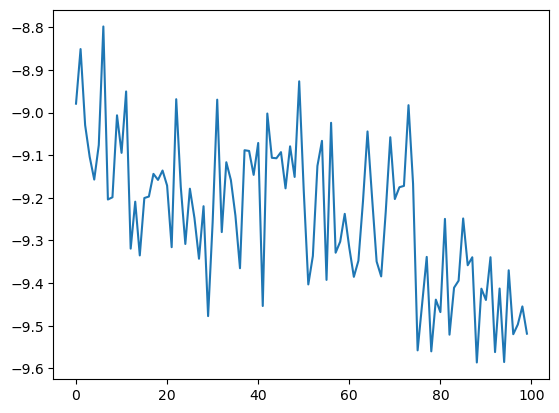

In [31]:
# Implement a function that returns the Black-Scholes price of a call option with given strike and maturity
def risk_neutral_price(S0, K, T, sigma):
    # for t = 0, since risk-free rate r = 0
    d_plus = 1/(sigma * np.sqrt(T)) * (np.log(S0 / K) + (0.5 * sigma**2) * (T))
    d_minus = d_plus - sigma * np.sqrt(T)

    price = S0 * norm.cdf(d_plus) - K * norm.cdf(d_minus)
    return price

# Train the model
dataset = TensorDataset(S_train)
model = DeepHedger(N=30)

# Define training hyperparameters
n_epochs = 100
lr = 1e-2 # learning rate
batch_size = 200
milestones = [75]

# Instantiate an optimizer (i.e. a (Stochastic) Gradient Descent algorithm)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# Instantiate a scheduler to decrease the learning rate during training according to a pre-defined rule
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=milestones, gamma=0.1)

# Create a batch loader from the dataset
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

p = risk_neutral_price(S0,K,T,sigma)

### Training
losses = torch.empty(n_epochs)
training_loop = tqdm(range(n_epochs)) 
for epoch in training_loop:
    
    # At each epoch iterate over batches
    for (x,) in loader:
        # compute training loss on batch
        S_T = x[:, -1]
        loss = torch.mean((call_payoff(S_T,K) - p - model(x))**2)
        # compute gradient of training loss wrt parameters
        loss.backward()
        # do one gradient step
        optimizer.step()
        # reset the computational graph        
        optimizer.zero_grad()
        
    
    # Print loss in the progression bar
    training_loop.set_postfix(loss = loss.item())
    
    # decrease learning rate according to scheduler's settings
    scheduler.step()

    # save training loss for plotting
    losses[epoch] = loss.item()

plt.plot(torch.log(losses), label='Training loss')
plt.show()


### Question 1.e - Model evaluation

Mean of hedging losses:  -3.231708979001269e-05
Std of hedging losses:  0.009161845780909061


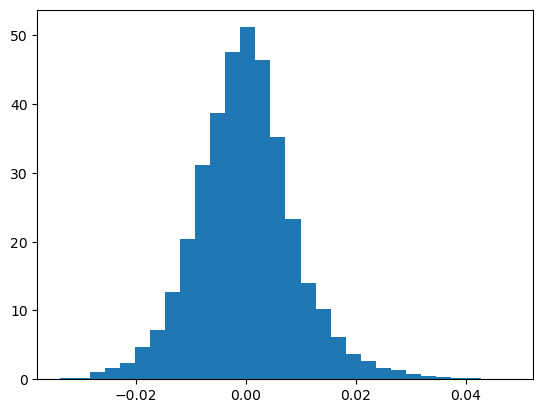

In [35]:
# Evaluate the hedging losses on the test set
with torch.no_grad():
    S_T_test = S_test[:, -1]
    hedging_losses = call_payoff(S_T_test, K) - p - model(S_test)


# Plot a histogram of the hedging losses and print mean and standard deviation
plt.hist(hedging_losses.numpy(), bins=30, density=True)
print("Mean of hedging losses: ", torch.mean(hedging_losses).item())
print("Std of hedging losses: ", torch.std(hedging_losses).item())

### Question 1.f(i) - Compute analytical solution

Show a **step-by-step** derivation of the analytical hedging strategy:

\begin{align*}
H^{\text{BS}}_t(s) & = \frac{\partial C(s, t)}{\partial s} \\
& = \ldots
\end{align*}

# Black–Scholes hedge (delta) derivation

We want a closed form for the hedge
$$
H_t^{\mathrm{BS}}(s) = \frac{\partial C(s,t)}{\partial s},
$$
where the Black–Scholes call price is
$$
C(s,t) = \Phi(d_+(s,t))\,s - \Phi(d_-(s,t))\,K e^{-r(T-t)}.
$$

Define
$$
d_+(s,t) =
\frac{\ln\left(\frac{s}{K}\right) + \left(r+\frac{\sigma^2}{2}\right)(T-t)}
     {\sigma\sqrt{T-t}},
\qquad
d_-(s,t) = d_+(s,t) - \sigma\sqrt{T-t}.
$$

Here $\Phi$ is the standard normal cdf and $\varphi$ its pdf.

Let $\tau := T - t$ for brevity.

---

## 1. Derivatives of \(d_+\) and \(d_-\)

Write
$$
d_+(s,t) = \frac{\ln\left(\frac{s}{K}\right)
           + \left(r+\frac{\sigma^2}{2}\right)\tau}
           {\sigma\sqrt{\tau}}.
$$

Only $\ln(s/K)$ depends on $s$, and
$$
\frac{\partial}{\partial s}\ln\left(\frac{s}{K}\right)
= \frac{1}{s}.
$$

Hence
$$
\frac{\partial d_+}{\partial s}
= \frac{1}{\sigma\sqrt{\tau}}\cdot\frac{1}{s}
= \frac{1}{s\sigma\sqrt{\tau}}.
$$

Since $d_- = d_+ - \sigma\sqrt{\tau}$ (constant shift in $s$),
$$
\frac{\partial d_-}{\partial s}
= \frac{\partial d_+}{\partial s}
= \frac{1}{s\sigma\sqrt{\tau}}.
$$

---

## 2. Derivative of the price

We have
$$
C(s,t) = \Phi(d_+)s - \Phi(d_-)K e^{-r\tau}.
$$

Differentiate w.r.t. $s$:

- First term:
  $$
  \frac{\partial}{\partial s}[\Phi(d_+)s]
  = \Phi(d_+) + s\,\varphi(d_+)\frac{\partial d_+}{\partial s}
  = \Phi(d_+) + \frac{\varphi(d_+)}{\sigma\sqrt{\tau}}.
  $$

- Second term:
  $$
  \frac{\partial}{\partial s}[\Phi(d_-)K e^{-r\tau}]
  = K e^{-r\tau}\,\varphi(d_-)\frac{\partial d_-}{\partial s}
  = \frac{K e^{-r\tau}\varphi(d_-)}{s\sigma\sqrt{\tau}}.
  $$

With the minus sign:
$$
\frac{\partial C}{\partial s}
= \Phi(d_+) + \frac{\varphi(d_+)}{\sigma\sqrt{\tau}}
  - \frac{K e^{-r\tau}\varphi(d_-)}{s\sigma\sqrt{\tau}}.
$$

Factor the last two terms:
$$
\frac{\partial C}{\partial s}
= \Phi(d_+) + \frac{1}{\sigma\sqrt{\tau}}
\left(\varphi(d_+) - \frac{K e^{-r\tau}\varphi(d_-)}{s}\right).
$$

---

## 3. Identity \(s\varphi(d_+) = K e^{-r\tau}\varphi(d_-)\)

Consider
$$
R = \frac{s\varphi(d_+)}{K e^{-r\tau}\varphi(d_-)}.
$$

Using $\varphi(x) = \frac{1}{\sqrt{2\pi}}e^{-x^2/2}$,
$$
R = \frac{s}{K e^{-r\tau}}
    \exp\!\left(-\frac{d_+^2 - d_-^2}{2}\right).
$$

Since $d_- = d_+ - \sigma\sqrt{\tau}$,
$$
d_+^2 - d_-^2 = 2\sigma\sqrt{\tau}d_+ - \sigma^2\tau.
$$

Thus
$$
-\frac{1}{2}(d_+^2 - d_-^2)
= -\sigma\sqrt{\tau}d_+ + \frac{\sigma^2\tau}{2}.
$$

But
$$
\sigma\sqrt{\tau}d_+
= \ln\left(\frac{s}{K}\right)
  + \left(r+\frac{\sigma^2}{2}\right)\tau,
$$
so
$$
-\sigma\sqrt{\tau}d_+ + \frac{\sigma^2\tau}{2}
= -\ln\left(\frac{s}{K}\right) - r\tau.
$$

Hence
$$
\exp\!\left(-\frac{d_+^2 - d_-^2}{2}\right)
= \exp\!\left(-\ln\left(\frac{s}{K}\right) - r\tau\right)
= \frac{K}{s}e^{-r\tau},
$$
and therefore
$$
R = \frac{s}{K e^{-r\tau}} \cdot \frac{K}{s}e^{-r\tau} = 1.
$$

So
$$
s\varphi(d_+) = K e^{-r\tau}\varphi(d_-).
$$

Plugging back, the bracket is zero and we get
$$
\frac{\partial C}{\partial s} = \Phi(d_+).
$$

---

## 4. Final result

The Black–Scholes hedge (delta) is
$$
H_t^{\mathrm{BS}}(s)
= \Phi\!\left(
\frac{\ln\left(\frac{s}{K}\right)
      + \left(r+\frac{\sigma^2}{2}\right)(T-t)}
     {\sigma\sqrt{T-t}}
\right).
$$






No points for solutions without explicit derivation.

### Question 1.f(ii) - Losses comparison with analytical solution

Analytical Hedge - Mean of hedging losses:  -2.801626942527946e-05
Analytical Hedge - Std of hedging losses:  0.009051511995494366
Deep Hedge - Mean of hedging losses:  -3.231708979001269e-05
Deep Hedge - Std of hedging losses:  0.009161845780909061


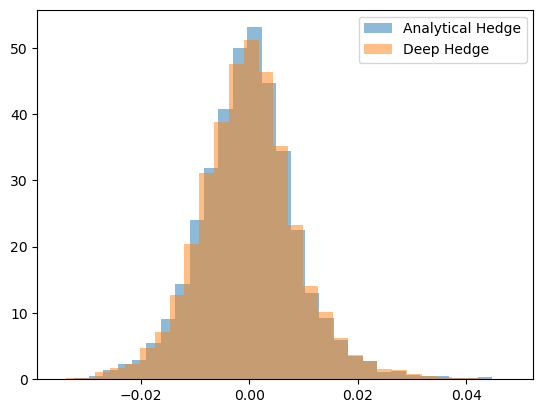

In [36]:
# Implement the formula you found
def analytical_hedge(s, t, K, T, sigma):
    d_plus = 1/(sigma * np.sqrt(T-t)) * (np.log(s / K) + (0.5 * sigma**2) * (T-t))
    delta = norm.cdf(d_plus)
    return delta

# Evaluate the losses of the analytical hedging strategies on the test set
with torch.no_grad():
    m_test = S_test.shape[0]
    analytical_hedging_integrals = torch.zeros(m_test)
    for j in range(N):
        S_tj   = S_test[:, j]
        S_tj1  = S_test[:, j+1]
        t_j    = j * (T / N)
        delta_j = analytical_hedge(S_tj.numpy(), t_j, K, T, sigma)
        dS_j    = S_tj1 - S_tj
        analytical_hedging_integrals += torch.from_numpy(delta_j).to(S_test.device) * dS_j

    analytical_hedging_losses = call_payoff(S_T_test, K) - p - analytical_hedging_integrals

# Plot a histograms of the hedging losses (analytical and deep hedging) and print means and standard deviations
plt.hist(analytical_hedging_losses.numpy(), bins=30, density=True, alpha=0.5, label='Analytical Hedge')
plt.hist(hedging_losses.numpy(), bins=30, density=True, alpha=0.5, label='Deep Hedge')
plt.legend()
print("Analytical Hedge - Mean of hedging losses: ", torch.mean(analytical_hedging_losses).item())
print("Analytical Hedge - Std of hedging losses: ", torch.std(analytical_hedging_losses).item())
print("Deep Hedge - Mean of hedging losses: ", torch.mean(hedging_losses).item())
print("Deep Hedge - Std of hedging losses: ", torch.std(hedging_losses).item())

How does your deep hedging model compare with the analytical solution? If it's worse, you must improve its performance. A few questions for you to consider...

Have you trained your deep hedging model well?
- Are the losses centered on zero? ($10^{-5} \approx 0$)
- Is their standard deviation comparable with that of the analytical solution?

How can you improve performance?
- train for more epochs
- try a different learning rate
- change the networks' architectures (first try more hidden neurons, then try more hidden layers)
- try different batch sizes
- use a learning rate scheduler (see https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate)
- try a different activation function (e.g. $\tanh$)
- implement regularization (use the `weight_decay` argument in the optimizer)
- implement batch-normalization (see https://pytorch.org/docs/stable/generated/torch.nn.BatchNorm1d.html)
- experiment with different optimizers
- ask in the forum

### Question 1.g - Learned strategy comparison with analytical solution

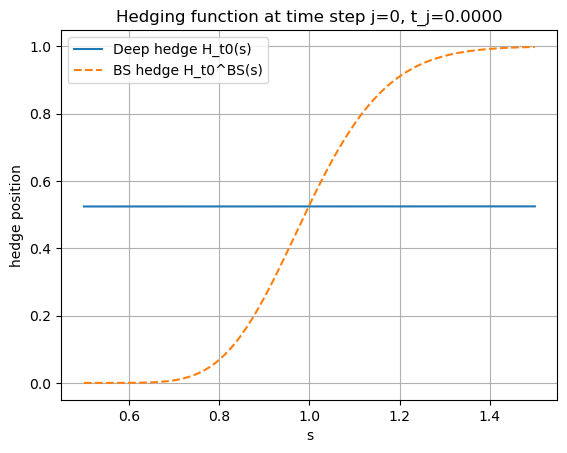

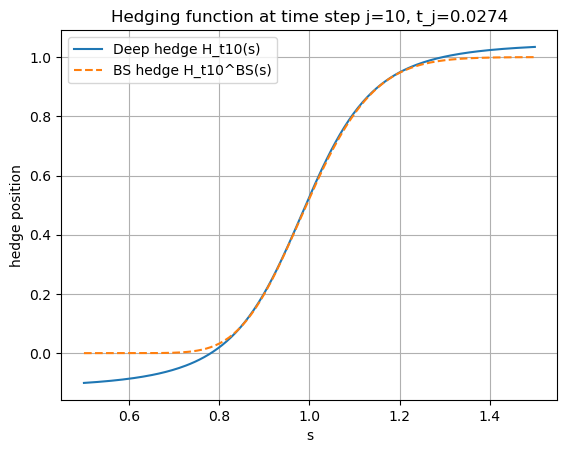

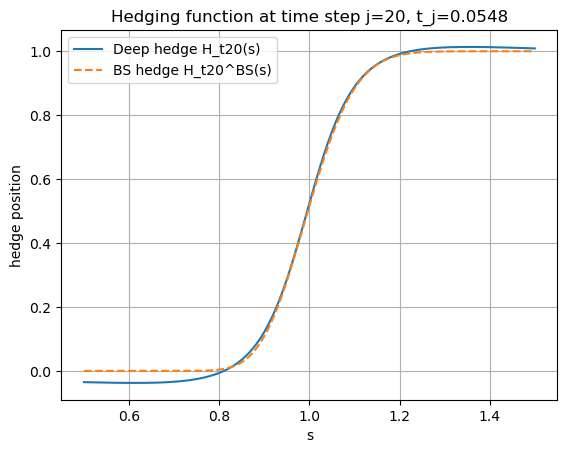

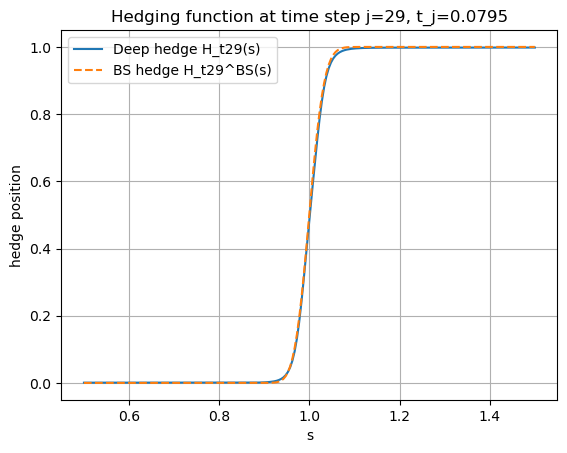

In [37]:
# Plot both the deep hedging strategies and the analytical hedging strategies
# assume you already have: model, analytical_hedge, K, T, sigma, N = 30

N = 30
js = [0, 10, 20, 29]

# grid of underlying prices s in [0.5, 1.5]
s_grid_np = np.linspace(0.5, 1.5, 200)
s_grid_torch = torch.from_numpy(s_grid_np.astype(np.float32)).unsqueeze(1)  # (200,1)

device = next(model.parameters()).device
s_grid_torch = s_grid_torch.to(device)

with torch.no_grad():
    for j in js:
        t_j = j * (T / N)   # current time

        # ----- NN hedge H_tj(s) -----
        H_nn = model.nets[j](s_grid_torch).squeeze(1).cpu().numpy()  # (200,)

        # ----- Analytical BS hedge H_tj^BS(s) -----
        # analytical_hedge expects numpy arrays
        H_bs = analytical_hedge(s_grid_np, t_j, K, T, sigma)         # (200,)

        # ----- Plot comparison -----
        plt.figure()
        plt.plot(s_grid_np, H_nn, label=f"Deep hedge H_t{j}(s)")
        plt.plot(s_grid_np, H_bs, label=f"BS hedge H_t{j}^BS(s)", linestyle="--")
        plt.xlabel("s")
        plt.ylabel("hedge position")
        plt.title(f"Hedging function at time step j={j}, t_j={t_j:.4f}")
        plt.legend()
        plt.grid(True)
        plt.show()


- For what times $t_j$ are the two functions most similar? 
- Answer: For later times more similar
- Why?
- Answer: Closer to maturity there is only a short time left and only a few rebalancings remaining, so the optimal discrete-time hedge is very close to the continuous-time Black-Scholes hedge.

# Exercise 2

In [38]:
from scipy.stats import ncx2

### Question 2.a - Generate dataset

In [39]:
# Set random seed for reproducibility
torch.manual_seed(3)

T = 30/365
N = 30
rho = -0.3
alpha_tilde = 4
b = 0.5
v_0 = 0.5
sigma = 1


# Write function to sample V
def sample_V(n_paths, T = T, N = N, alpha_tilde = alpha_tilde, b = b, sigma = sigma):
    V = torch.ones(size=(n_paths, N + 1))
    C = torch.ones(n_paths)
    c = sigma**2/(4*alpha_tilde)*(1-torch.exp(torch.tensor(-alpha_tilde*T/N)))

    for i in range(N):
        C = torch.tensor(ncx2.rvs(df=4*alpha_tilde*b/sigma**2, nc=V[:, i]*torch.exp(torch.tensor(-alpha_tilde*T/N)) / c, size=(n_paths, )))
        V[:, i+1] = c * C

    return V

# Write function to sample S
def sample_S(n_paths, V_rvs, T = T, N = N, rho = rho, sigma = sigma, alpha_tilde = alpha_tilde, b = b):
    Z = torch.randn((n_paths, N))
    S = torch.ones(size=(n_paths, N + 1))


    for i in range(N):
        S[:, i + 1] = S[:, i] * torch.exp(rho/sigma * ((V_rvs[:, i+1] - V_rvs[:, i]) - alpha_tilde*b*T/N)
                                    + (alpha_tilde*rho/sigma - 0.5) * V_rvs[:, i] * T/N
                                    + torch.sqrt((1-rho**2) * V_rvs[:, i] * T/N)* Z[:, i])

    return S

# Generate the training set

m_train = 100_000

V_train = sample_V(n_paths = m_train)
S_train = sample_S(n_paths = m_train, V_rvs = V_train)


# Generate the test set
m_test = 10_000

V_test = sample_V(n_paths = m_test)
S_test = sample_S(n_paths = m_test, V_rvs = V_test)

### Question 2.b - Model implementation

In [40]:
# Implement the deep hedging model for a generic alpha
class HestonNN(nn.Module):
    def __init__(self, N, nh1, nh2):
        super().__init__()
        self.N = N
        self.nets = nn.ModuleList([nn.Sequential(nn.Linear(1, nh1),
                          nn.ReLU(),
                          nn.Linear(nh1, nh2),
                          nn.Tanh(),
                          nn.Linear(nh2, 1)
                          ) for _ in range(N)])
        
        # Add the additional parameter w, initialized it to zero.
        self.w = nn.Parameter(torch.zeros(1, requires_grad=True))

    def forward(self, x):
        """
        x: tensor of shape (batch, N+1)
        """
        outputs = []
        for i in range(self.N):
            input_network_i = x[:, [i]]
            outputs.append(self.nets[i](input_network_i))
        return torch.cat(outputs, dim=1)
    

### Question 2.c - Model training

In [41]:
# Train two deep hedging models (for alpha=0.5 and alpha=0.99) for the call option
def heston_empirical_loss(payoff, S, alpha, w, nn_output):
  """
  payoff: (b, ) g(S_T) of the b paths
  S: (b, N+1) the b paths of size N+1
  alpha: (1, ) scalar value setting the level at which CVaR will be used as a risk measure, needs to be in (0, 1)
  w: (1, ) scalar value (parameter of neural network)
  nn_output: (b, N) the output of the N neural networks
  """

  return torch.mean(w + torch.maximum(payoff - torch.sum(nn_output * (S[:, 1:] - S[:, :-1]), dim=1, keepdim=True) - w, torch.zeros_like(payoff)) / (1 - alpha))


  0%|          | 0/40 [00:00<?, ?it/s]

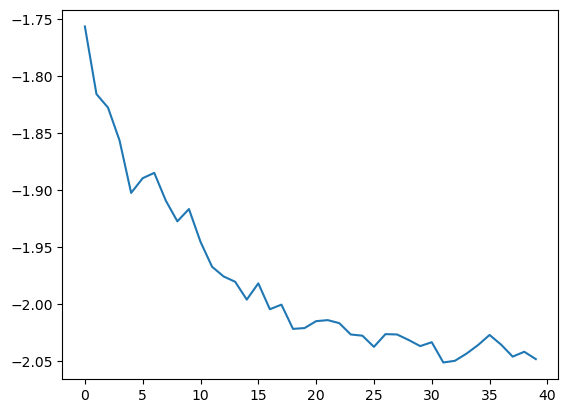

In [42]:
# Model 1: alpha=0.5
alpha = 0.5
torch.manual_seed(6)
# Number of neurons in hidden layers
nh1 = 16 # first hidden layer
nh2 = 32 # second hidden layer

heston_nn_0p5 = HestonNN(N=N, nh1=nh1, nh2=nh2)

# Define training hyperparameters
n_epochs = 40
lr = 1e-3 # learning rate
batch_size = 1000
milestones = [75]

# Instantiate an optimizer (i.e. a (Stochastic) Gradient Descent algorithm)
optimizer = torch.optim.Adam(heston_nn_0p5.parameters(), lr=lr)

# Instantiate a scheduler to decrease the learning rate during training according to a pre-defined rule
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=milestones, gamma=0.1)

# Create a batch loader from the dataset
loader = DataLoader(S_train, batch_size=batch_size, shuffle=True)
losses = torch.empty(n_epochs)
training_loop = tqdm(range(n_epochs))
for epoch in training_loop:

  # At each epoch iterate over batches
  for batch in loader:
    S_T = batch[:, [-1]]
    payoff = call_payoff(S_T, K)
    nn_output = heston_nn_0p5(batch)

    # compute training loss on batch
    loss = heston_empirical_loss(payoff, batch, alpha=alpha, w=heston_nn_0p5.w, nn_output=nn_output)
    # reset the computational graph
    optimizer.zero_grad()
    # compute gradient of training loss wrt parameters
    loss.backward()
    # do one gradient step
    optimizer.step()


    # Print loss in the progression bar
    training_loop.set_postfix(loss = loss.item())
    # decrease learning rate according to scheduler's settings
    scheduler.step()

    # save training loss for plotting
    losses[epoch] = loss.item()
plt.plot(torch.log(losses), label=f'Training loss of NN')
plt.show()



### Question 2.d - Price comparison

  0%|          | 0/60 [00:00<?, ?it/s]

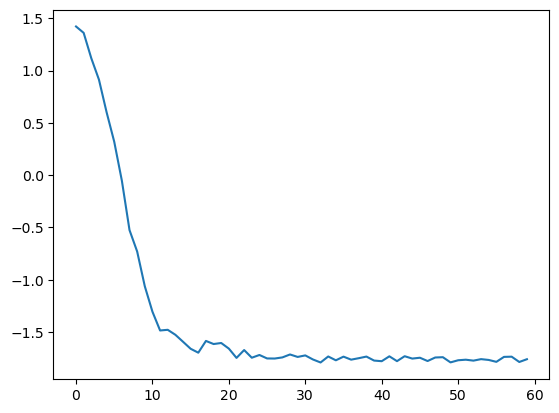

In [43]:
# Model 2: alpha=0.99
alpha = 0.99

torch.manual_seed(7)
# Number of neurons in hidden layers
nh1 = 32 # first hidden layer
nh2 = 32 # second hidden layer

heston_nn_0p99 = HestonNN(N=N, nh1=nh1, nh2=nh2)

# Define training hyperparameters
n_epochs = 60
lr = 1e-3 # learning rate
batch_size = 1000
milestones = [75]

# Instantiate an optimizer (i.e. a (Stochastic) Gradient Descent algorithm)
optimizer = torch.optim.Adam(heston_nn_0p99.parameters(), lr=lr)

# Instantiate a scheduler to decrease the learning rate during training according to a pre-defined rule
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=milestones, gamma=0.1)

# Create a batch loader from the dataset
loader = DataLoader(S_train, batch_size=batch_size, shuffle=True)
losses = torch.empty(n_epochs)
training_loop = tqdm(range(n_epochs))
for epoch in training_loop:

  # At each epoch iterate over batches
  for batch in loader:
    S_T = batch[:, [-1]]
    payoff = call_payoff(S_T, K)
    nn_output = heston_nn_0p99(batch)


    # compute training loss on batch
    loss = heston_empirical_loss(payoff, batch, alpha=alpha, w=heston_nn_0p99.w, nn_output=nn_output)
    # reset the computational graph
    optimizer.zero_grad()
    # compute gradient of training loss wrt parameters
    loss.backward()
    # do one gradient step
    optimizer.step()
  


    # Print loss in the progression bar
    training_loop.set_postfix(loss = loss.item())

    # decrease learning rate according to scheduler's settings
    scheduler.step()

    # save training loss for plotting
    losses[epoch] = loss.item()
plt.plot(torch.log(losses), label=f'Training loss of NN')
plt.show()

In [44]:
# Print the prices p for alpha=0.5 and alpha=0.99
# Which one is higher? Why?

with torch.no_grad():
    payoff_test = call_payoff(S_test[:, [-1]], K)
    nn_output_0p5_test = heston_nn_0p5(S_test)
    nn_output_0p99_test = heston_nn_0p99(S_test)
    p_0p5 = heston_empirical_loss(payoff_test, S_test, alpha=0.5, w=heston_nn_0p5.w, nn_output=nn_output_0p5_test)
    p_0p99 = heston_empirical_loss(payoff_test, S_test, alpha=0.99, w=heston_nn_0p99.w, nn_output=nn_output_0p99_test)
    # one is expected value
    # other one is essential supremum


    # compute the prices using empirical function equation (6)
    print(f"Empirical price for alpha=0.5: {p_0p5.item():.5f}") #.item() converts it to float.
    print(f"Empirical price for alpha=0.99: {p_0p99.item():.5f}")




Empirical price for alpha=0.5: 0.12895
Empirical price for alpha=0.99: 0.16946


With a higher alpha, you care about the worst 1% of scenarios and therefore for the extreme tail losses. To make these tail losses small, the optimizer needs more initial capital p and will therefore choose a more conservative hedging strategy, which results in a higher price. A more tail-risk-averse risk measure demands a larger premium.

### Question 2.e - Price comparison

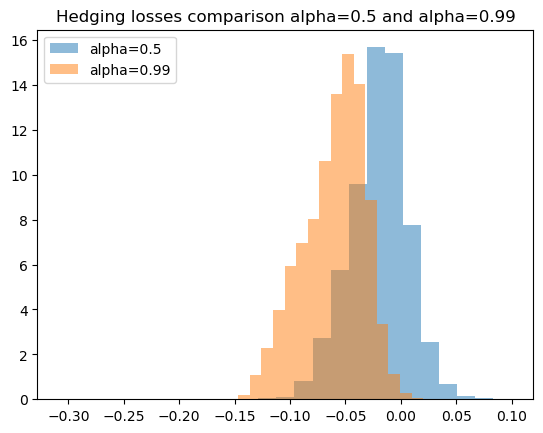

Mean of alpha=0.5 losses on test set: -0.02038589119911194, Standard deviation: 0.026564626023173332
Mean of alpha=0.99 losses on test set: -0.06050308793783188, Standard deviation: 0.027883732691407204


In [45]:
def portfolio_loss(payoff, p, S, nn_output):
  return payoff - p - torch.sum(nn_output * (S[:, 1:] - S[:, :-1]), dim=1, keepdim=True) # keepdim=True in order to get correct shape ()


# Plot a histograms of the hedging losses (for alpha=0.5 and alpha=0.99) and print means and standard deviations
hedging_losses_0p5 = portfolio_loss(payoff_test, p=p_0p5, S=S_test, nn_output=nn_output_0p5_test)
hedging_losses_0p99 = portfolio_loss(payoff_test, p=p_0p99, S=S_test, nn_output=nn_output_0p99_test)


plt.hist(hedging_losses_0p5.detach().cpu().numpy(), bins=25, label="alpha=0.5", alpha=0.5, density=True)
plt.hist(hedging_losses_0p99.detach().cpu().numpy(), bins=25, label="alpha=0.99", alpha=0.5, density=True)
plt.legend()
plt.title("Hedging losses comparison alpha=0.5 and alpha=0.99")
plt.show()

print(f"Mean of alpha=0.5 losses on test set: {torch.mean(hedging_losses_0p5)}, Standard deviation: {torch.std(hedging_losses_0p5)}")
print(f"Mean of alpha=0.99 losses on test set: {torch.mean(hedging_losses_0p99)}, Standard deviation: {torch.std(hedging_losses_0p99)}")